# Exercício 02 — Classificação Binária de Imagens Térmicas (Motor)

**Objetivo:** classificar imagens térmicas do motor entre:
- `M` (Médio) → **carga normal** → classe `0`
- `F` (Full) → **carga máxima / sobrecarga** → classe `1`

**Pipeline:**
1. Carregar e pré-processar as imagens (`Treino_H_F`, `Treino_H_M`, `Teste_H_F`, `Teste_H_M`)
2. Vetorizar (flatten) e padronizar os pixels
3. Treinar 5 algoritmos com ajuste de hiperparâmetros (GridSearchCV): KNN, Árvore de Decisão, Random Forest, SVM linear, SVM polinomial grau 2
4. Avaliar cada um via matriz de confusão no conjunto de teste
5. Montar um ensemble por voto majoritário e comparar com os modelos individuais

> Estrutura de pastas usada (relativa à raiz do repo):
> ```
> imgs/Bases_Img_Termica_Motor/
>   ├── Treino_H_F/   (treino, carga máxima)
>   ├── Treino_H_M/   (treino, carga normal)
>   ├── Teste_H_F/    (teste, carga máxima)
>   └── Teste_H_M/    (teste, carga normal)
> ```

## 0. Instalação das dependências

Rode esta célula uma vez (pode comentar/pular depois se já tiver tudo instalado).

In [1]:
%pip install -q numpy pandas matplotlib pillow scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Carregamento e pré-processamento das imagens

Cada imagem é convertida para escala de cinza, redimensionada para um tamanho fixo
(reduz dimensionalidade e custo computacional) e depois transformada em vetor (flatten).

`IMG_SIZE` é o único parâmetro que vale a pena testar variar (ex: 32x32 vs 64x64) caso
queira avaliar o trade-off entre detalhe da imagem e tempo de treino.

In [12]:
import os
import glob
import numpy as np
from PIL import Image

# 440x280 Padrão

np.random.seed(42)

BASE_DIR = "imgs/Bases_Img_Termica_Motor"
IMG_SIZE = (110, 70)  # (largura, altura) -- ajuste se quiser mais/menos detalhe
# Proporcção 1/3

# 0 = carga normal (Médio) | 1 = carga máxima / sobrecarga (Full)
PASTAS = {
    "train": {"F": "Treino_H_F", "M": "Treino_H_M"},
    "test":  {"F": "Teste_H_F",  "M": "Teste_H_M"},
}

def carregar_pasta(caminho, label):
    imagens, labels = [], []
    arquivos = sorted(glob.glob(os.path.join(caminho, "*.jpg")))
    for arq in arquivos:
        img = Image.open(arq).convert("L")          # escala de cinza
        img = img.resize(IMG_SIZE)                   # tamanho fixo
        imagens.append(np.array(img, dtype=np.uint8))
        labels.append(label)
    return imagens, labels

def montar_conjunto(split):
    imgs_f, lab_f = carregar_pasta(os.path.join(BASE_DIR, PASTAS[split]["F"]), 1)
    imgs_m, lab_m = carregar_pasta(os.path.join(BASE_DIR, PASTAS[split]["M"]), 0)
    imagens = imgs_f + imgs_m
    labels = lab_f + lab_m
    return np.array(imagens), np.array(labels)

imgs_train, y_train = montar_conjunto("train")
imgs_test, y_test = montar_conjunto("test")

print(f"Treino: {imgs_train.shape[0]} imagens | Teste: {imgs_test.shape[0]} imagens")
print(f"Dimensão de cada imagem: {imgs_train.shape[1:]}")
print(f"Distribuição treino -> normal(0): {(y_train==0).sum()} | máxima(1): {(y_train==1).sum()}")
print(f"Distribuição teste  -> normal(0): {(y_test==0).sum()} | máxima(1): {(y_test==1).sum()}")

Treino: 143 imagens | Teste: 54 imagens
Dimensão de cada imagem: (70, 110)
Distribuição treino -> normal(0): 55 | máxima(1): 88
Distribuição teste  -> normal(0): 27 | máxima(1): 27


### Visualização rápida de amostras

Conferência visual antes de seguir — confirma que o carregamento e os rótulos
(`0` = normal, `1` = máxima) estão corretos.

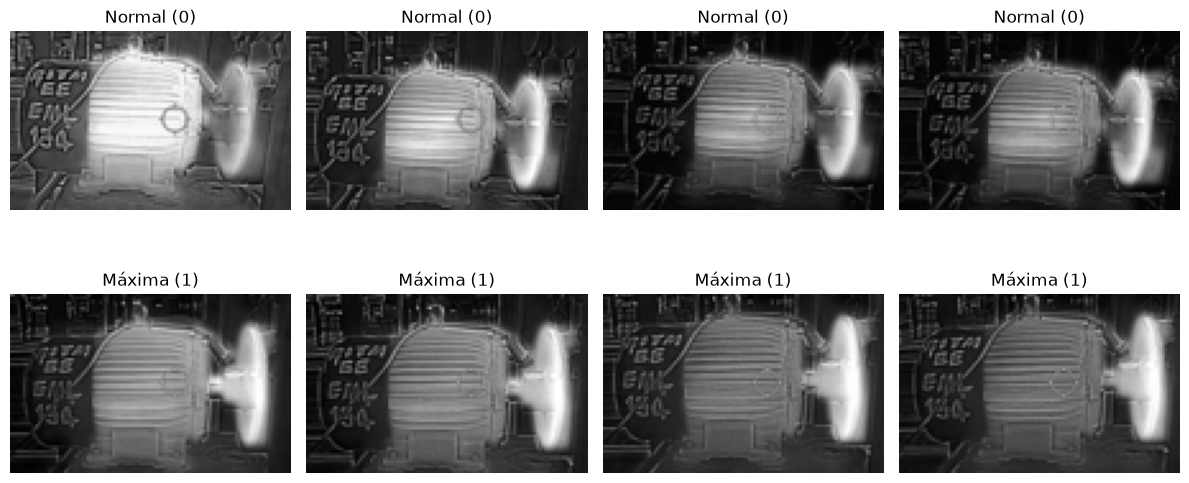

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
idx_normal = np.where(y_train == 0)[0][:4]
idx_maxima = np.where(y_train == 1)[0][:4]

for ax, i in zip(axes[0], idx_normal):
    ax.imshow(imgs_train[i], cmap="gray")
    ax.set_title("Normal (0)")
    ax.axis("off")

for ax, i in zip(axes[1], idx_maxima):
    ax.imshow(imgs_train[i], cmap="gray")
    ax.set_title("Máxima (1)")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2. Vetorização (flatten) e padronização

Cada imagem (matriz `IMG_SIZE x IMG_SIZE`) vira um vetor de pixels (linha de `X`).
O `StandardScaler` é ajustado **apenas no treino** e aplicado igualmente no teste,
para evitar vazamento de informação (data leakage). Isso é importante principalmente
para KNN e SVM, que são sensíveis à escala dos atributos.

In [17]:
from sklearn.preprocessing import StandardScaler

X_train = imgs_train.reshape(imgs_train.shape[0], -1).astype(np.float64)
X_test = imgs_test.reshape(imgs_test.shape[0], -1).astype(np.float64)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train_scaled.shape)
print("X_test :", X_test_scaled.shape)

X_train: (143, 7700)
X_test : (54, 7700)


## 3. Treinamento dos algoritmos (com ajuste de hiperparâmetros)

Para cada algoritmo, usamos `GridSearchCV` (validação cruzada interna) para buscar os
principais hiperparâmetros. Os melhores estimadores ficam guardados em `modelos_treinados`
para serem reaproveitados nas etapas de avaliação e no ensemble.

Ajuste os grids (`param_grid`) livremente conforme o tamanho da sua base — grids maiores
custam mais tempo de execução.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

param_grids = {
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "param_grid": {
            "n_neighbors": [3, 5, 7, 9, 11], # vizinhos a serem buscados
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan"],
        },
    },
    "Arvore de Decisao": {
        "estimator": DecisionTreeClassifier(random_state=42),
        "param_grid": {
            "max_depth": [3, 5, 8, 12, None],
            "min_samples_split": [2, 5, 10],
            "criterion": ["gini", "entropy"],
        },
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=42),
        "param_grid": {
            "n_estimators": [100, 200, 300],
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5],
        },
    },
    "SVM Linear": {
        "estimator": SVC(kernel="linear", random_state=42),
        "param_grid": {
            "C": [0.01, 0.1, 1, 10, 100],
        },
    },
    "SVM Polinomial (grau 2)": {
        "estimator": SVC(kernel="poly", degree=2, random_state=42),
        "param_grid": {
            "C": [0.1, 1, 10],
            "coef0": [0, 1, 5],
            "gamma": ["scale", "auto"],
        },
    },
}

modelos_treinados = {}
melhores_params = {}

for nome, config in param_grids.items():
    print(f"Treinando: {nome} ...")
    grid = GridSearchCV(
        estimator=config["estimator"],
        param_grid=config["param_grid"],
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
    )
    grid.fit(X_train_scaled, y_train)
    modelos_treinados[nome] = grid.best_estimator_
    melhores_params[nome] = grid.best_params_
    print(f"  Melhores parâmetros: {grid.best_params_}")
    print(f"  Acurácia média (CV): {grid.best_score_:.4f}\n")

Treinando: KNN ...


  Melhores parâmetros: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
  Acurácia média (CV): 0.8892

Treinando: Arvore de Decisao ...
  Melhores parâmetros: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
  Acurácia média (CV): 0.8537

Treinando: Random Forest ...
  Melhores parâmetros: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
  Acurácia média (CV): 0.8956

Treinando: SVM Linear ...
  Melhores parâmetros: {'C': 0.01}
  Acurácia média (CV): 0.9022

Treinando: SVM Polinomial (grau 2) ...
  Melhores parâmetros: {'C': 0.1, 'coef0': 5, 'gamma': 'scale'}
  Acurácia média (CV): 0.9167



## 4. Avaliação individual — matriz de confusão e métricas

Para cada modelo treinado: predição no conjunto de teste, matriz de confusão e
`classification_report` (precisão, recall, f1-score por classe).

=== KNN ===
Acurácia: 0.7963 | F1-score: 0.8136
              precision    recall  f1-score   support

  Normal (0)       0.86      0.70      0.78        27
  Máxima (1)       0.75      0.89      0.81        27

    accuracy                           0.80        54
   macro avg       0.81      0.80      0.79        54
weighted avg       0.81      0.80      0.79        54



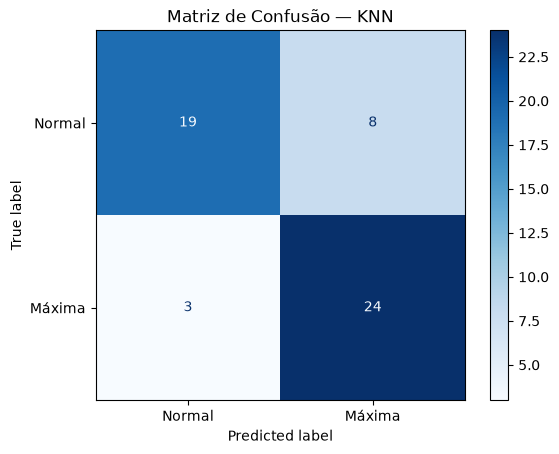

=== Arvore de Decisao ===
Acurácia: 0.8333 | F1-score: 0.8364
              precision    recall  f1-score   support

  Normal (0)       0.85      0.81      0.83        27
  Máxima (1)       0.82      0.85      0.84        27

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54



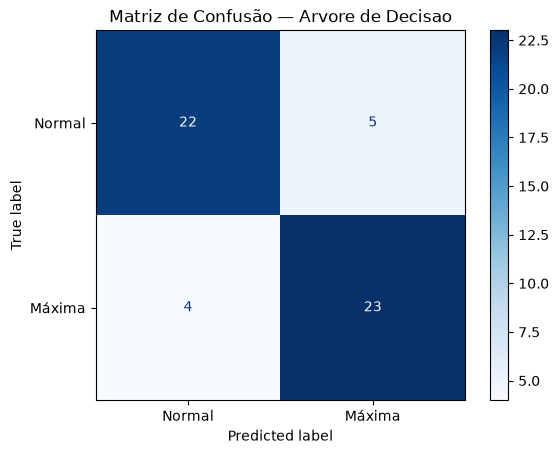

=== Random Forest ===
Acurácia: 0.8148 | F1-score: 0.8333
              precision    recall  f1-score   support

  Normal (0)       0.90      0.70      0.79        27
  Máxima (1)       0.76      0.93      0.83        27

    accuracy                           0.81        54
   macro avg       0.83      0.81      0.81        54
weighted avg       0.83      0.81      0.81        54



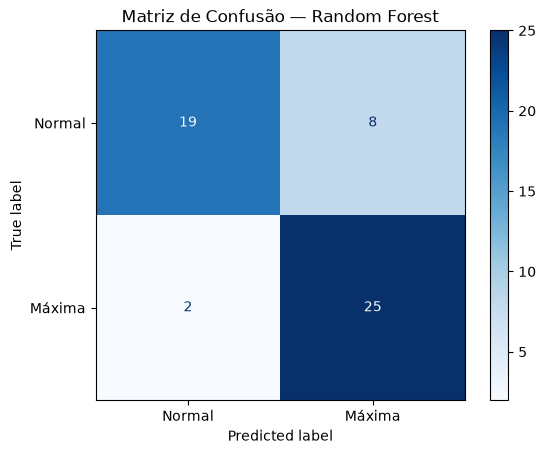

=== SVM Linear ===
Acurácia: 0.8333 | F1-score: 0.8525
              precision    recall  f1-score   support

  Normal (0)       0.95      0.70      0.81        27
  Máxima (1)       0.76      0.96      0.85        27

    accuracy                           0.83        54
   macro avg       0.86      0.83      0.83        54
weighted avg       0.86      0.83      0.83        54



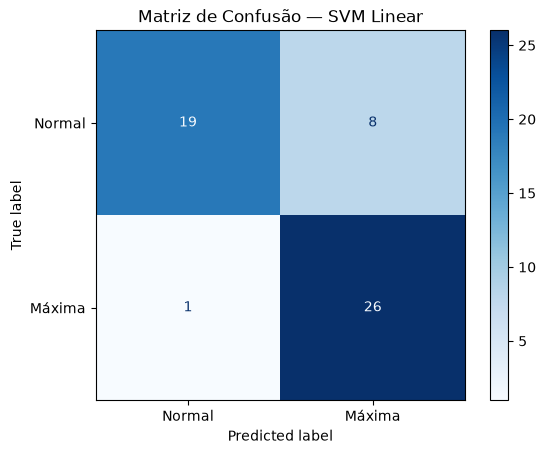

=== SVM Polinomial (grau 2) ===
Acurácia: 0.8333 | F1-score: 0.8475
              precision    recall  f1-score   support

  Normal (0)       0.91      0.74      0.82        27
  Máxima (1)       0.78      0.93      0.85        27

    accuracy                           0.83        54
   macro avg       0.85      0.83      0.83        54
weighted avg       0.85      0.83      0.83        54



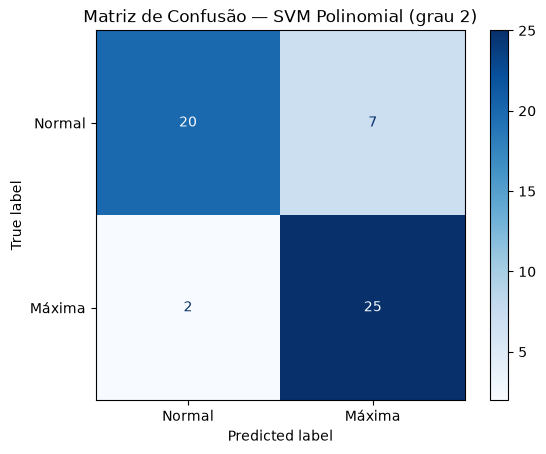

In [6]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score, f1_score
)

def avaliar_modelo(nome, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"=== {nome} ===")
    print(f"Acurácia: {acc:.4f} | F1-score: {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Normal (0)", "Máxima (1)"]))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Máxima"])
    disp.plot(cmap="Blues")
    plt.title(f"Matriz de Confusão — {nome}")
    plt.show()

    return {"modelo": nome, "acuracia": acc, "f1": f1, "y_pred": y_pred}

resultados = []
for nome, modelo in modelos_treinados.items():
    resultados.append(avaliar_modelo(nome, modelo, X_test_scaled, y_test))

## 5. Ensemble (voto da maioria)

`VotingClassifier` com `voting="hard"` combina as predições de classe (não as
probabilidades) dos 5 modelos já ajustados, decidindo por voto majoritário.

=== Ensemble (Voto Majoritário) ===
Acurácia: 0.8333 | F1-score: 0.8475
              precision    recall  f1-score   support

  Normal (0)       0.91      0.74      0.82        27
  Máxima (1)       0.78      0.93      0.85        27

    accuracy                           0.83        54
   macro avg       0.85      0.83      0.83        54
weighted avg       0.85      0.83      0.83        54



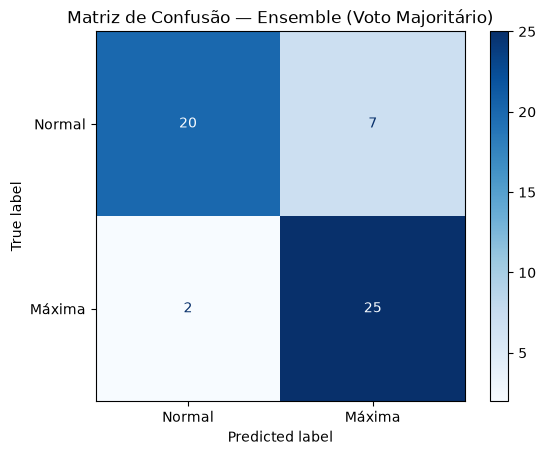

In [7]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[(nome, modelo) for nome, modelo in modelos_treinados.items()],
    voting="hard",
)

# Como os estimadores já vieram do GridSearchCV (já treinados/ajustados),
# o fit do ensemble apenas reaproveita o ajuste e confere os rótulos de classe.
ensemble.fit(X_train_scaled, y_train)

resultado_ensemble = avaliar_modelo("Ensemble (Voto Majoritário)", ensemble, X_test_scaled, y_test)
resultados.append(resultado_ensemble)

## 6. Comparação final

Tabela-resumo com acurácia e F1-score de todos os modelos + ensemble, para
discutir qual abordagem performou melhor e por quê.

In [8]:
import pandas as pd

df_resultados = pd.DataFrame(
    [{"Modelo": r["modelo"], "Acurácia": r["acuracia"], "F1-score": r["f1"]} for r in resultados]
).sort_values("Acurácia", ascending=False).reset_index(drop=True)

df_resultados

,Modelo,Acurácia,F1-score
0,Arvore de Decisao,0.833333,0.836364
1,SVM Linear,0.833333,0.852459
2,Ensemble (Voto Majoritário),0.833333,0.847458
3,SVM Polinomial (grau 2),0.833333,0.847458
4,Random Forest,0.814815,0.833333
5,KNN,0.796296,0.813559


## 7. Discussão (pontos para a apresentação)

- Qual modelo teve o melhor desempenho individual? Faz sentido dado o tipo de dado
  (imagem térmica, alta dimensionalidade, poucas amostras)?
- O ensemble superou o melhor modelo individual? Em que situações o voto majoritário
  tende a ajudar (modelos com erros pouco correlacionados) ou atrapalhar (um modelo
  fraco "puxando" a decisão)?
- Olhando a matriz de confusão: os erros são mais de falso positivo (normal
  classificado como máxima) ou falso negativo (máxima classificado como normal)?
  No contexto do problema (proteção do motor), qual erro é mais caro?
- O `IMG_SIZE` escolhido afetou o resultado? Vale a pena testar outro tamanho?